Let's quantify the separation relative to baseline that we observed.

In [1]:
import warnings

warnings.resetwarnings()

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*__version__ is deprecated.*"
)

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"Observation names are not unique.*"
)

warnings.filterwarnings(
    "ignore",
    module=r"scanpy(\..*)?$"
)

warnings.filterwarnings(
    "ignore",
    module=r"anndata(\..*)?$"
)

warnings.filterwarnings("ignore", module=r"scanpy(\..*)?$")
warnings.filterwarnings("ignore", module=r"anndata(\..*)?$")
warnings.filterwarnings("ignore", message="Observation names are not unique.*")
warnings.filterwarnings("ignore", message="`__version__` is deprecated.*")
warnings.filterwarnings('ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ImportWarning)

from anndata._warnings import ImplicitModificationWarning
warnings.filterwarnings(
    "ignore",
    category=ImplicitModificationWarning
)


In [2]:
import os
import sys
import warnings
import math
from contextlib import contextmanager
import copy
from collections import defaultdict

from tqdm import trange, tqdm

import numpy as np
import pandas as pd
import scanpy as sc

from scipy import stats
import statsmodels.api as sm
from scipy.spatial.distance import mahalanobis

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from PIL import Image
from IPython.display import display
Image.MAX_IMAGE_PIXELS = None  

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls
from scLEMBAS.metrics import distances
from scLEMBAS.metrics import differential_expression as scl_de

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)



In [4]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

cf_pls_models = io.read_pickled_object(
    os.path.join(data_path, 'interim', '{}_counterfactual_PLS_models.pickle')
)

n_folds = 5
ls_label_dict = {
    'pls': 'LV', 
    'pca': 'PC'
}

tc_per_fold = {}
for fold in range(n_folds):
    split = get_split(fold, author)
    tc_per_fold[fold] = split['test_conds']
    
    
merged_adatas = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_model_predictions.pickle'.format(author))
)

merged_adatas_noadv = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_noadv_predictions.pickle'.format(author))
)

merged_adatas_rand = io.read_pickled_object(
    os.path.join(data_path, 'processed', '{}_scLEMBAS_rand_predictions.pickle'.format(author))
)


In [22]:
def clear_adata(adata):
    for k in copy.deepcopy(adata.obsm.keys()):
        del adata.obsm[k]
    for k in copy.deepcopy(adata.varm.keys()):
        del adata.varm[k]
    for k in copy.deepcopy(adata.obsp.keys()):
        del adata.obsp[k]
    
    return adata

def load_cf_tf_adata(merged_adatas, fold, test_cond, key: str = 'none', project = True, include_pred_ctrl = True):

    key_ = '{}_{}'.format(key, fold)
    tf_adata_merged = merged_adatas[key_].copy()

    # filter for condition of interest
    ct, pert = test_cond.split('^')
    ctrl_cond = '^'.join([ct, ctrl_pert])
    cf_mask = tf_adata_merged.obs.condition.isin([test_cond, ctrl_cond])

    tf_adata_test = tf_adata_merged[cf_mask,:].copy()

    a = tf_adata_test.obs.cell_type.nunique() == 1
    b = tf_adata_test.obs.ligand.nunique() == 2
    c = sorted(tf_adata_test.obs.batch.unique()) == ['actual', 'predicted', 'predicted_ctrl']
    assert a and b and c, 'Incorrect counterfactual condition filtering'

    # split between actual and predicted
    actual_mask = (tf_adata_test.obs.batch == 'actual')
    tf_adata_actual = tf_adata_test[actual_mask, :].copy()
    
#   pred_mask = ~actual_mask # THIS SHOULD WORK FOR KANG
    pred_test = (tf_adata_test.obs.batch == 'predicted')
    pred_ctrl = (tf_adata_test.obs.batch == 'predicted_ctrl') & (tf_adata_test.obs.control_for == pert)
    pred_mask = pred_test | pred_ctrl if include_pred_ctrl else pred_test
    tf_adata_predicted = tf_adata_test[pred_mask, :].copy()


    n_pred_check =  tf_adata.obs.condition.value_counts().loc[ctrl_cond]
    if include_pred_ctrl:
        assert tf_adata_predicted.n_obs == n_pred_check*2, 'Incorrect counterfactual condition filtering'
    else:
        assert tf_adata_predicted.n_obs == n_pred_check, 'Incorrect counterfactual condition filtering'
    
    # project to PLS space
    tf_adata_actual = clear_adata(tf_adata_actual)
    tf_adata_predicted = clear_adata(tf_adata_predicted)
    if project:
        pls_model = cf_pls_models[test_cond]

        X_actual_pls = pls_model.transform(tf_adata_actual.X)
        tf_adata_actual.obsm['X_pls'] = X_actual_pls

        X_pred_pls = pls_model.transform(tf_adata_predicted.X)
        tf_adata_predicted.obsm['X_pls'] = X_pred_pls
    
    return tf_adata_actual, tf_adata_predicted

# Perturbation Distance

We take the mahalanobis distance between the mean centroids of each perturbation and its control in PLS space

In [13]:
distance_metric = 'mahalanobis' # 'euclidean'

In [7]:
def cohens_d_paired(a, b):
    """
    Paired Cohen's d.
    Positive d => mean(a) > mean(b)
    """
    diff = a - b
    return diff.mean() / diff.std(ddof=1)


def pb_distance_ed(adata):
    X_pls = pd.DataFrame(adata.obsm['X_pls'])
    X_pls[pert_col] = adata.obs[pert_col].astype(str).tolist()
    X_pls = X_pls.groupby(pert_col).mean()
    ed = np.linalg.norm(X_pls.iloc[0, :] - X_pls.iloc[1, :])
    
    return ed


def pb_distance_mahalanobis(adata):
    X_pls = pd.DataFrame(adata.obsm['X_pls'])
    X_pls[pert_col] = adata.obs[pert_col].astype(str).tolist()

    # centroids
    pert_centroids = X_pls.groupby(pert_col).mean()
    mu1 = pert_centroids.iloc[0].values
    mu2 = pert_centroids.iloc[1].values

    # pooled within-group covariance
    X_centered = X_pls.copy()
    X_centered.iloc[:, :-1] = (
        X_centered.iloc[:, :-1]
        - X_centered.groupby(pert_col).transform("mean")
    )

    cov = np.cov(X_centered.iloc[:, :-1].values, rowvar=False)

    VI = np.linalg.inv(cov)

    md = mahalanobis(mu1, mu2, VI)
    return md

pb_distance = pb_distance_ed if distance_metric == 'euclidean' else pb_distance_mahalanobis

mads = dict(zip(
    ['actual', 'noadv'], 
    [merged_adatas, merged_adatas_noadv]
))

In [11]:
pw_distances = defaultdict(list)

for mt, mad in mads.items():
    for fold, test_conds in tc_per_fold.items():
        for test_cond in test_conds: 
            tf_adata_actual, tf_adata_predicted = load_cf_tf_adata(mad, fold, test_cond, key = 'none',
                                                                   project = True, include_pred_ctrl = True
                                                                  )

            ed_actual = pb_distance(tf_adata_actual)
            ed_pred = pb_distance(tf_adata_predicted)

            pw_distances['test condition'].append(test_cond)
            pw_distances['actual'].append(ed_actual)
            pw_distances['predicted'].append(ed_pred)  
            pw_distances['mod_type'].append(mt)
            
pw_distances = pd.DataFrame(pw_distances)

pw_distances['error'] = np.abs(pw_distances["predicted"] - pw_distances["actual"]) # / np.sqrt(2)


In [12]:
mt_map = {
    'actual': 'scLEMBAS', 
    'noadv': 'scLEMBAS - No Adversarial Removal'
}
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 9,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    }
)

''

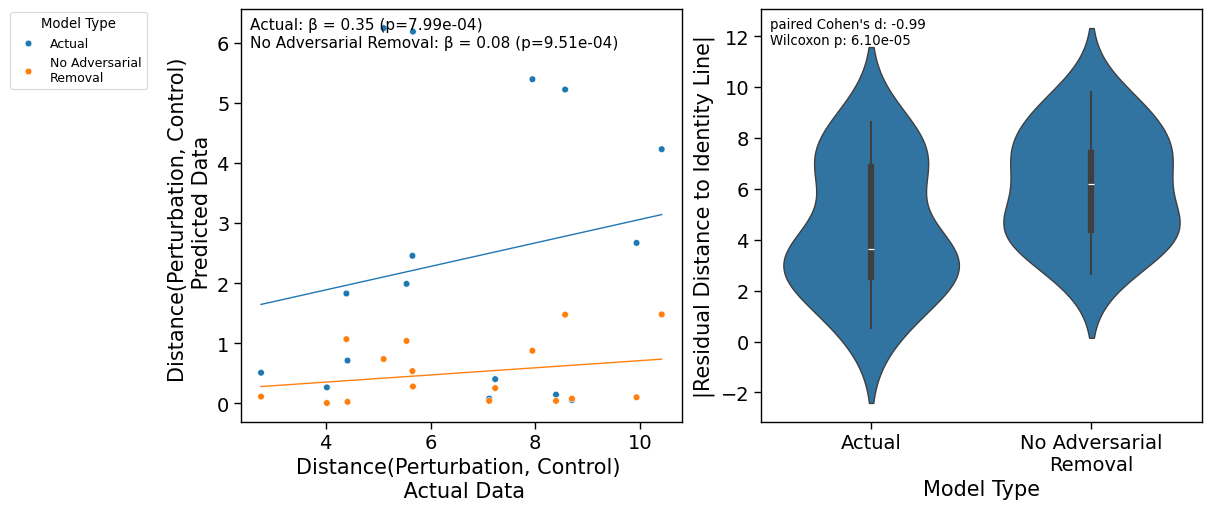

In [13]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5), constrained_layout = True)

j = 0

sns.scatterplot(data = pw_distances, x = 'actual', y = 'predicted', hue = 'mod_type', ax = ax[j], zorder = 2)

for mod_type in ['actual', 'noadv']:
    viz_df = pw_distances[pw_distances.mod_type == mod_type].copy()

    sns.regplot(
        data=viz_df,
        x="actual",
        y="predicted",
        ax=ax[j],
        scatter=False,      
        ci = None,
        line_kws={"linewidth": 1}, 
    )

    
# pearson
# pr_actual = stats.pearsonr(pw_distances[pw_distances.mod_type == 'actual'].actual,
#                            pw_distances[pw_distances.mod_type == 'actual'].predicted).statistic
# pr_noadv = stats.pearsonr(pw_distances[pw_distances.mod_type == 'noadv'].actual,
#                           pw_distances[pw_distances.mod_type == 'noadv'].predicted).statistic

# ax[j].text(
#     0.02, 0.98,
#     "{}: r = {:.2f}\n{}: r = {:.2f}".format(mt_map['actual'], pr_actual, mt_map['noadv'], pr_noadv),
#     transform=ax[j].transAxes,
#     ha="left", va="top"
# )

# OLS coefficient
# --- actual model ---
x = pw_distances[pw_distances.mod_type == 'actual'].actual.values
y = pw_distances[pw_distances.mod_type == 'actual'].predicted.values

res = sm.OLS(y, x).fit()   # no intercept
beta_actual = res.params[0]
pval_actual = res.pvalues[0]

# --- no-adversarial model ---
x = pw_distances[pw_distances.mod_type == 'noadv'].actual.values
y = pw_distances[pw_distances.mod_type == 'noadv'].predicted.values

res = sm.OLS(y, x).fit()   # no intercept
beta_noadv = res.params[0]
pval_noadv = res.pvalues[0]

ax[j].text(
    0.02, 0.98,
    "{}: β = {:.2f} (p={:.2e})\n{}: β = {:.2f} (p={:.2e})".format(
        'Actual', beta_actual, pval_actual,
        'No Adversarial Removal', beta_noadv, pval_noadv
    ),
    transform = ax[j].transAxes,
    ha = "left",
    va = "top", 
    fontsize = 11, 
)

ax[j].set_xlabel('Distance(Perturbation, Control) \n Actual Data')
ax[j].set_ylabel('Distance(Perturbation, Control) \n Predicted Data')

ax_min = np.min([pw_distances.actual.min(), pw_distances.predicted.min()])
ax_max = np.max([pw_distances.actual.max(), pw_distances.predicted.max()])

# ax[j].set_xlim(ax_min, ax_max)
# ax[j].set_ylim(ax_min, ax_max)

# ax[j].plot(
#     [ax_min, ax_max],
#     [ax_min, ax_max],
#     linestyle="--",
#     color="gray",
#     linewidth=1,
#     zorder=0
# )

handles, labels = ax[j].get_legend_handles_labels()
ax[j].legend(
    handles = handles, labels = ['Actual', 'No Adversarial\nRemoval'], title = 'Model Type', 
    loc="center right",
    bbox_to_anchor=(-0.2, 0.9),
    frameon=True
)


j = 1
a = pw_distances[pw_distances.mod_type == 'actual']['error'].values
b = pw_distances[pw_distances.mod_type == 'noadv']['error'].values
cd = cohens_d_paired(a, b)
pval = stats.wilcoxon(a, b).pvalue


sns.violinplot(data = pw_distances, x = 'mod_type', y = 'error', ax = ax[j])
ax[j].set_xlabel('Model Type')


ax[j].text(
    0.02, 0.98,
    f"paired Cohen's d: {cd:.2f}\nWilcoxon p: {pval:.2e}",
    transform=ax[j].transAxes,
    ha="left", va="top"
)

ticks = ax[j].get_xticks()
ax[j].set_xticks(ticks)
ax[j].set_xticklabels(['Actual', 'No Adversarial\nRemoval'])
ax[j].set_ylabel('|Residual Distance to Identity Line|')
;

Left panel: scatter plots of the perturbation - control Mahalanobis distance for each test condition, comparing predicted to actual distances for each model type. Annotations are the OLS regression coefficient, with values closer to 1 (actual = predicted, y = x) being better). OLS is fit without an intercept because we are comparing to the line y = x. 

Right panel: absolute residual orthogonal distance of scatter points to the line y = x (in other words, distance from (actual, predicted) to (actual, actual) coordinates). Higher residuals mean less accurate. 

Distances were calculated in PLS space

These plots essentially show that, relative to the appropriate baseline, the model is capturing counterfactual perturbation separation via adversarial training, 

# Differential Expression

A more mechanistic assessment of separation of control and perturbation is differential expression. 

- Not subsampling seems to give very consistent results with subsampling median, but we will subsample for statistical soundness
- Since we have a random baseline, we don't generate a null distribution

In [17]:
mads = dict(zip(
    ['actual', 'noadv', 'random'], 
    [merged_adatas, merged_adatas_noadv, merged_adatas_rand]
))


In [154]:
c_fn = os.path.join(data_path, 'processed', '{}_de_concordance.csv'.format(author))
if not os.path.isfile(c_fn):
    n_total = 0
    for mt, mad in mads.items():
        for fold, test_conds in tc_per_fold.items():
            for test_cond in test_conds: 
                n_total += 1


    concordance_df = []
    counter = 0
    for mt, mad in mads.items():
        for fold, test_conds in tc_per_fold.items():
            for test_cond in test_conds: 
                counter += 1
                print('{} of {}'.format(counter, n_total), flush = True)

                tf_adata_actual, tf_adata_predicted = load_cf_tf_adata(mad, fold, test_cond, key = 'none', 
                                                                      project=False, include_pred_ctrl = False)


                de_res = scl_de.concordance_pipeline(
                    tf_adata_actual = tf_adata_actual, 
                    tf_adata_predicted = tf_adata_predicted, 
                    test_condition = (test_cond.split('^')[0], test_cond.split('^')[1]), 
                    pert_col = pert_col, 
                    cat_col = cat_col, 
                    ctrl_var = ctrl_pert, 
                    counterfactual = 'perturbation', 
                    n_subsample = 100,
                    n_permutation = None, # using the random baseline instead
                    alpha = 0.05, 
                    rank_by = 'effect_size', 
                    concordance_metric = 'jaccard', 
                    seed = seed, 
                    n_cores = 34
                )

                pos_concordance, neg_concordance, _, _ = de_res
                
                # basic formatting
                pos_concordance.reset_index(inplace = True)
                pos_concordance.columns.name = None
                pos_concordance['rank'] += 1
                neg_concordance.reset_index(inplace = True)
                neg_concordance.columns.name = None
                neg_concordance['rank'] += 1
                
                # record the types
                pos_concordance['direction'] = 'positive'
                neg_concordance['direction'] = 'negative'

                concordance = pd.concat([pos_concordance, neg_concordance], axis = 0, ignore_index = True)
                concordance['test_condition'] = test_cond
                concordance['mod_type'] = mt

                concordance_df.append(concordance)

    concordance_df = pd.concat(concordance_df, ignore_index = True)
    concordance_df.to_csv(c_fn)

else:
    concordance_df = pd.read_csv(c_fn, index_col = 0)


In [156]:
concordance_df.tail()

,direction,test_condition,mod_type,rank,subsample_iteration,jaccard_index
1036079,negative,Goblet^IL13,Random,58,99,0.160000
1036080,negative,Goblet^IL13,Random,59,99,0.168317
1036081,negative,Goblet^IL13,Random,60,99,0.176471
1036082,negative,Goblet^IL13,Random,61,99,0.173077
1036083,negative,Goblet^IL13,Random,62,99,0.180952


In [155]:
concordance_df = pd.melt(concordance_df, id_vars=['direction', 'test_condition', 'mod_type', 'rank'],
        value_name = 'jaccard_index', var_name = 'subsample_iteration'
       )
concordance_df = concordance_df[concordance_df.jaccard_index.notna()]

concordance_df.mod_type = pd.Categorical(
    concordance_df.mod_type, 
    categories = ['actual', 'random', 'noadv'], 
    ordered = True
).map(
    {'actual': 'Actual', 
    'random': 'Random', 
    'noadv': 'No Adversarial Removal'}
)

In [139]:
palette = {
    'Actual': sns.color_palette('Set1')[1], 
    'Random': sns.color_palette('Set1')[0], 
    'No Adversarial Removal': sns.color_palette('Set1')[-1]
}

def plot_concordance_panel(concordance_df, test_cond, ax):
    viz_df = concordance_df[concordance_df.test_condition == test_cond]
    for mod_type in viz_df.mod_type.cat.categories:
        sns.regplot(
            viz_df[viz_df['mod_type'] == mod_type],
            x='rank', y='jaccard_index',
            ci=None, scatter=False,
            color=palette[mod_type],
            ax=ax,
            lowess = True, 
            seed = seed, 
            label=mod_type
        )
    ax.set_ylabel('DE Concordance (Jaccard Index)')
    ax.set_xlabel('Feature Rank')
    ax.set_title(' '.join(test_cond.split('^')))
    ax.legend()

Text(0.5, 0.98, 'Upregulated TFs')

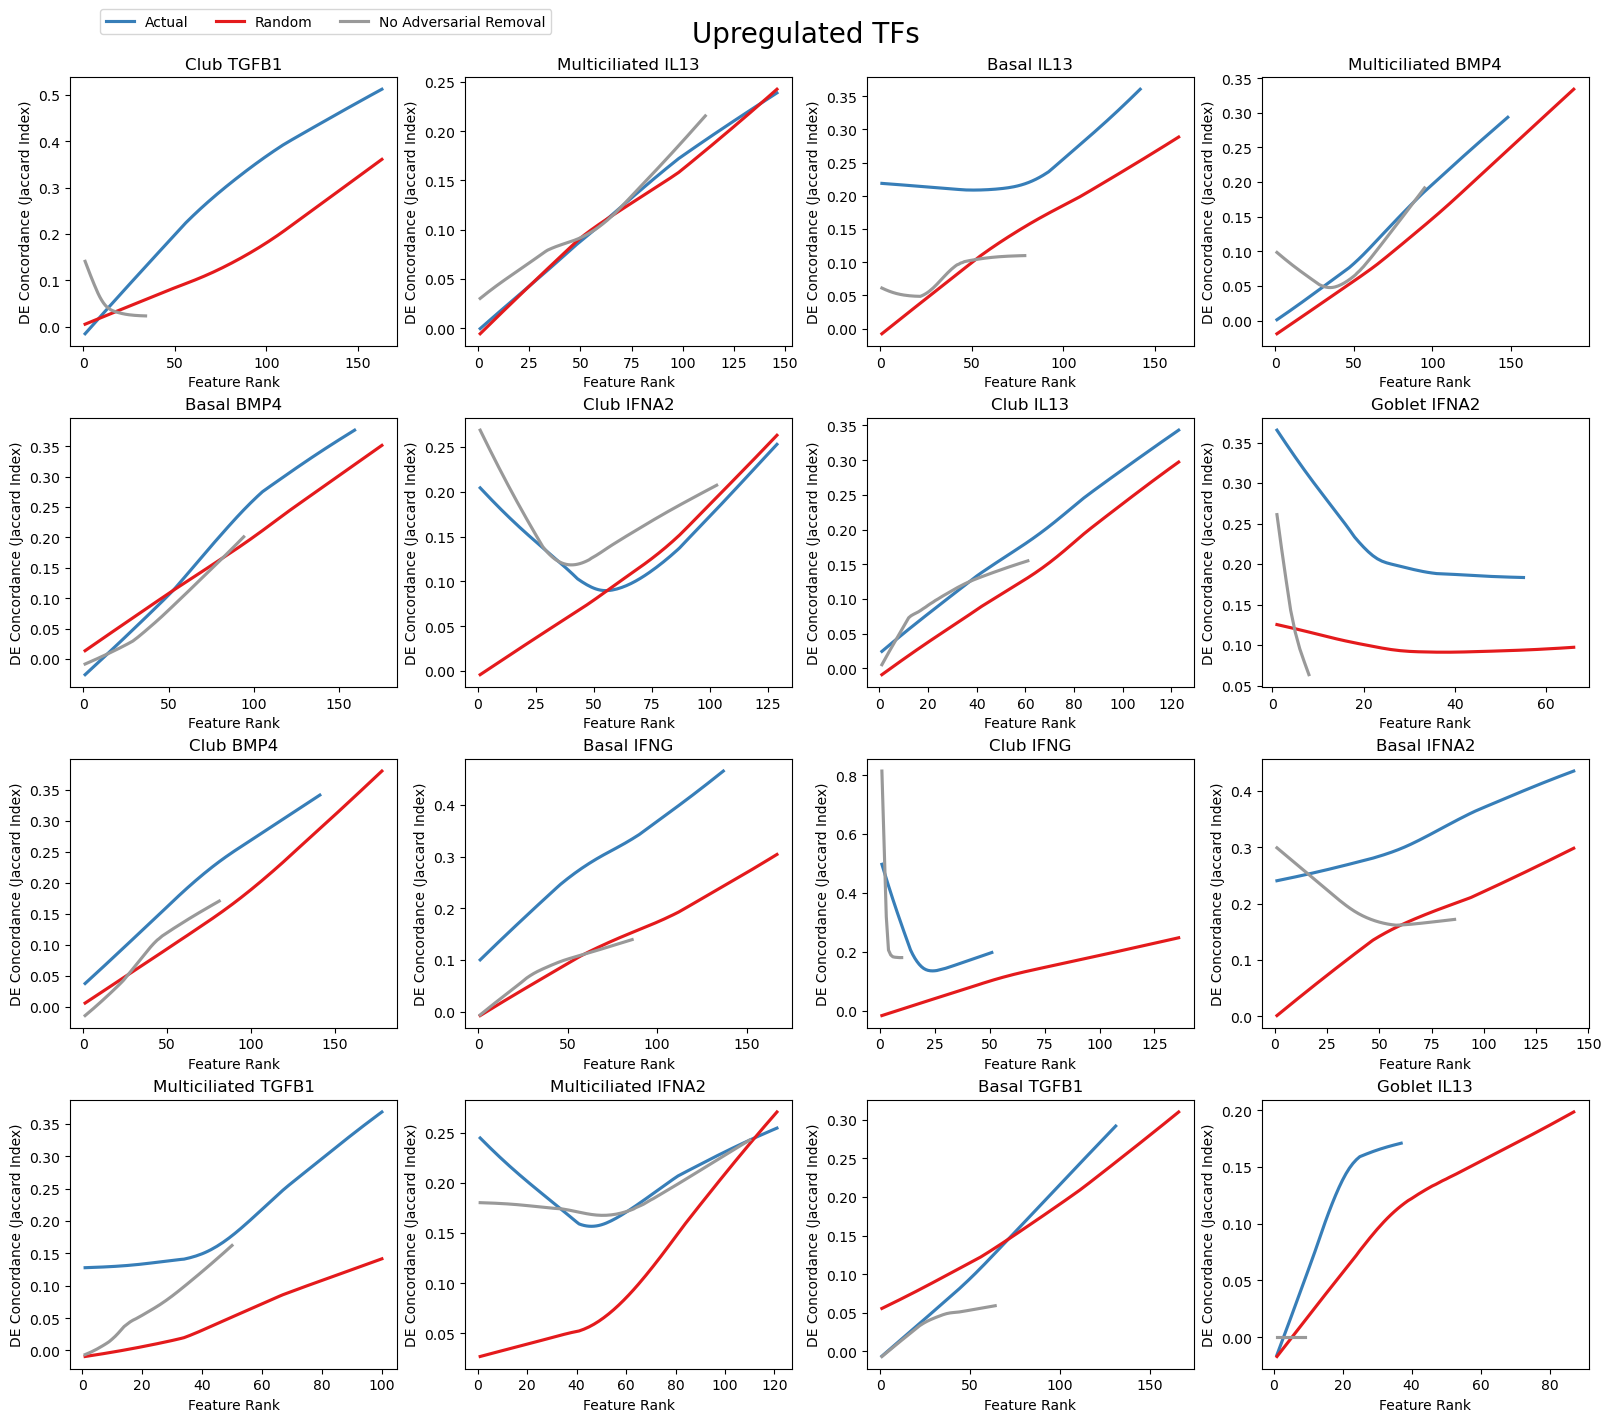

In [146]:
direction = 'positive'
directional_concordance_df = concordance_df[concordance_df.direction == direction].copy()

n_test_conds = directional_concordance_df.test_condition.nunique()


ncols = min(4, n_test_conds)
nrows = math.ceil(n_test_conds / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), constrained_layout=True)
axes_flat = axes.ravel()

# ---- your plotting loop ----
for (i, test_cond) in enumerate(directional_concordance_df.test_condition.unique()):
    plot_concordance_panel(concordance_df = directional_concordance_df, test_cond = test_cond, ax = axes_flat[i])

# ---- remove empty panels ----
for j in range(n_test_conds, len(axes_flat)):
    fig.delaxes(axes_flat[j])
    
    
leg = axes_flat[0].get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.2, 1.01)
)

for i in range(n_test_conds):
    axes_flat[i].legend_.remove()

fig.suptitle('Upregulated TFs', fontsize = 20)

Text(0.5, 0.98, 'Upregulated TFs')

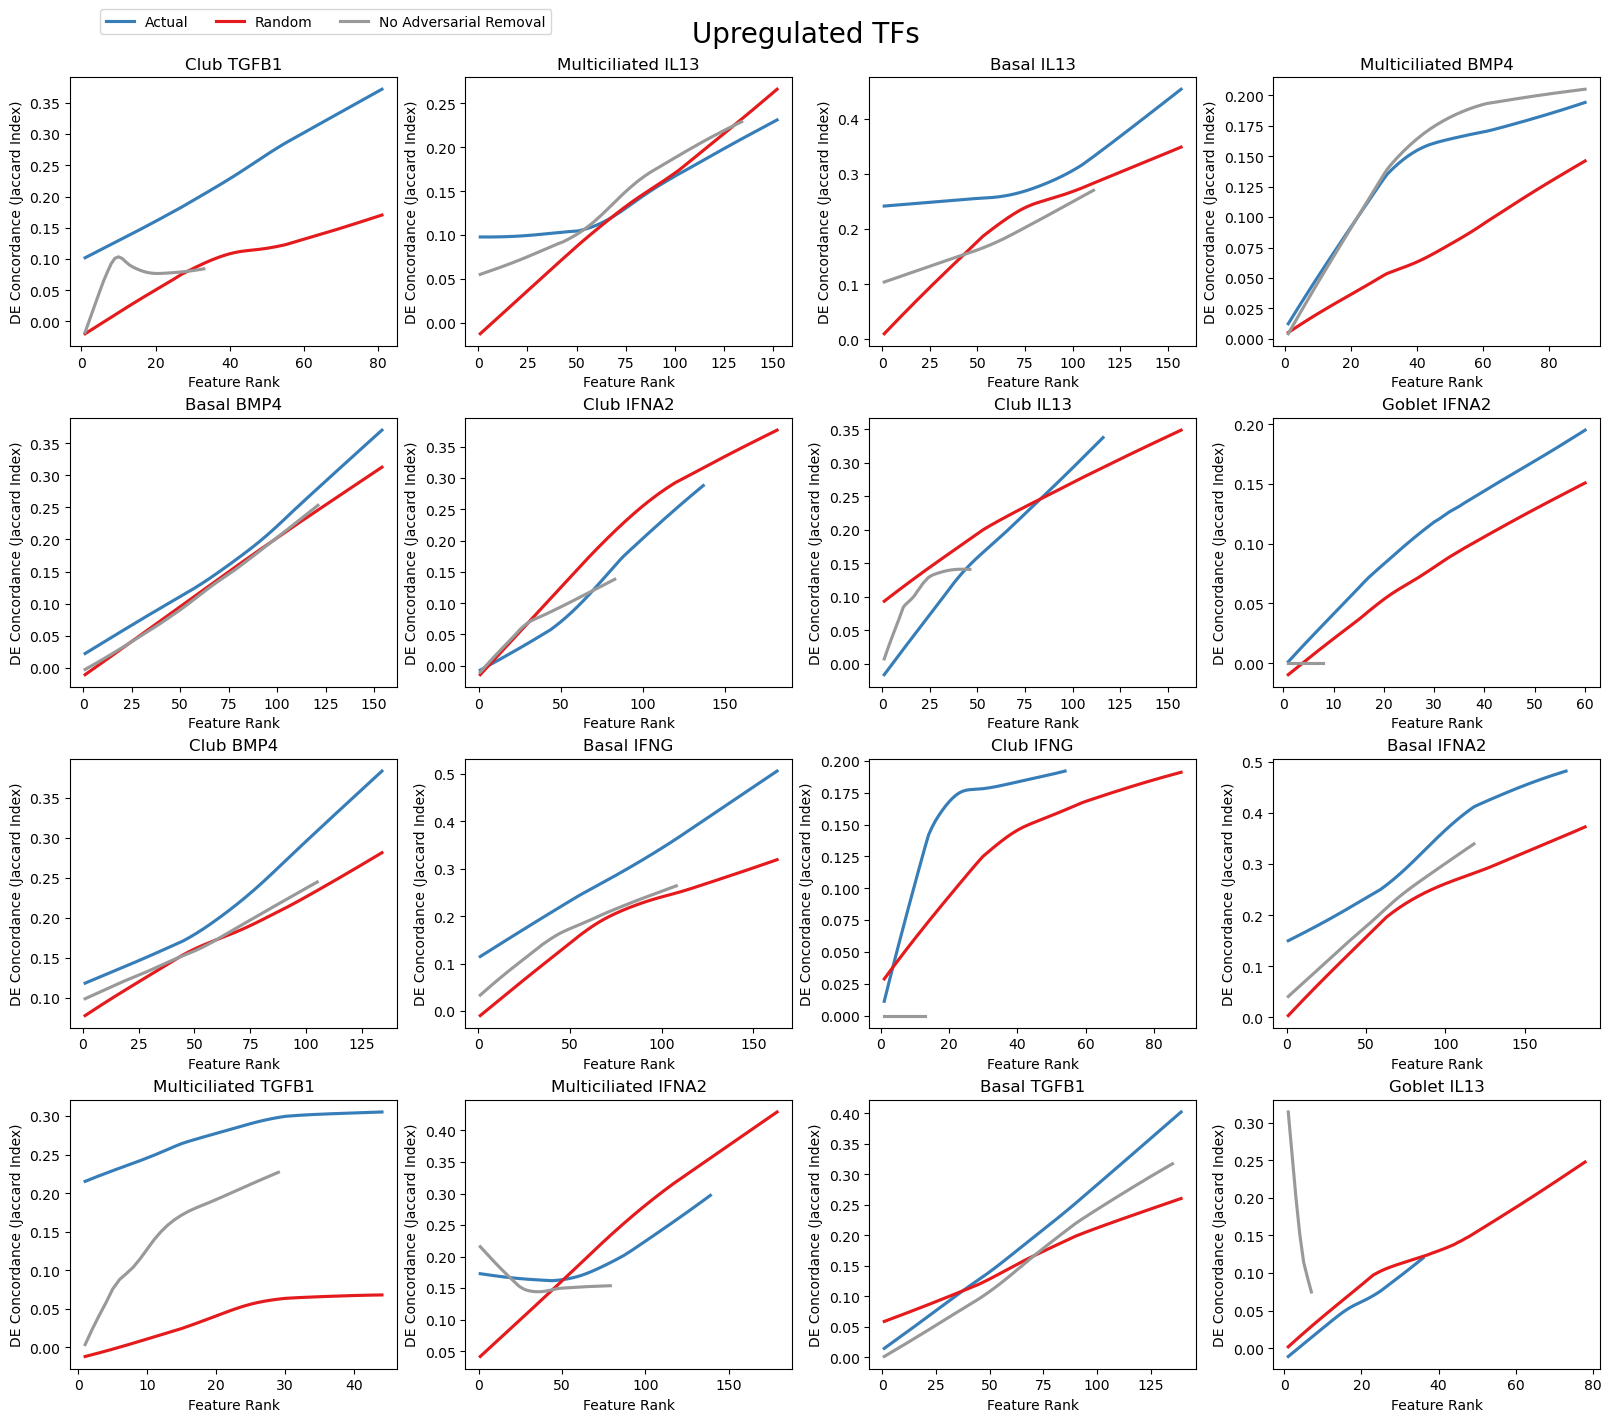

In [148]:
direction = 'negative'
directional_concordance_df = concordance_df[concordance_df.direction == direction].copy()

n_test_conds = directional_concordance_df.test_condition.nunique()


ncols = min(4, n_test_conds)
nrows = math.ceil(n_test_conds / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), constrained_layout=True)
axes_flat = axes.ravel()

# ---- your plotting loop ----
for (i, test_cond) in enumerate(directional_concordance_df.test_condition.unique()):
    plot_concordance_panel(concordance_df = directional_concordance_df, test_cond = test_cond, ax = axes_flat[i])

# ---- remove empty panels ----
for j in range(n_test_conds, len(axes_flat)):
    fig.delaxes(axes_flat[j])
    
    
leg = axes_flat[0].get_legend()
handles = leg.legend_handles
labels = [t.get_text() for t in leg.get_texts()]

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.2, 1.01)
)

for i in range(n_test_conds):
    axes_flat[i].legend_.remove()

fig.suptitle('Upregulated TFs', fontsize = 20)

# start